# Классификация типа стекол

This is a Glass Identification Data Set from UCI. It contains 10 attributes including id. The response is glass type(discrete 7 values).

Attribute Information:

- Id number: 1 to 214 (removed from CSV file)
- RI: refractive index
- Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
- Mg: Magnesium
- Al: Aluminum
- Si: Silicon
- K: Potassium
- Ca: Calcium
- Ba: Barium
- Fe: Iron
- Type of glass: (class attribute)
-
-- 1 building_windows_float_processed

-- 2 building_windows_non_float_processed

-- 3 vehicle_windows_float_processed

-- 4 vehicle_windows_non_float_processed (none in this database)

-- 5 containers

-- 6 tableware

-- 7 headlamps

## Загружаю датасет

In [8]:
!pip install -q kagglehub==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 8.1 MB/s eta 0:00:00


In [10]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/glass",
    "glass.csv",
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'glass' dataset.
First 5 records:         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


## Первичный анализ

Количество записей для каждого класса

In [11]:
data['Type'].value_counts().sort_index()

,count
Type,
1,70
2,76
3,17
5,13
6,9
7,29


# Разделяю датасет

In [14]:
from sklearn.model_selection import train_test_split

X = data.drop('Type', axis=1)
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"Признаков: {X_train.shape[1]}")

Обучающая выборка: 171 строк
Тестовая выборка: 43 строк
Признаков: 9


## Дерево решений

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print('Случайный лес готов!!')

Случайный лес готов!!


## Точность предсказаний случайного леса

In [21]:
from sklearn.metrics import classification_report
y_pred_rf = rf_model.predict(X_test)

print (classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



## Обработка выбросов

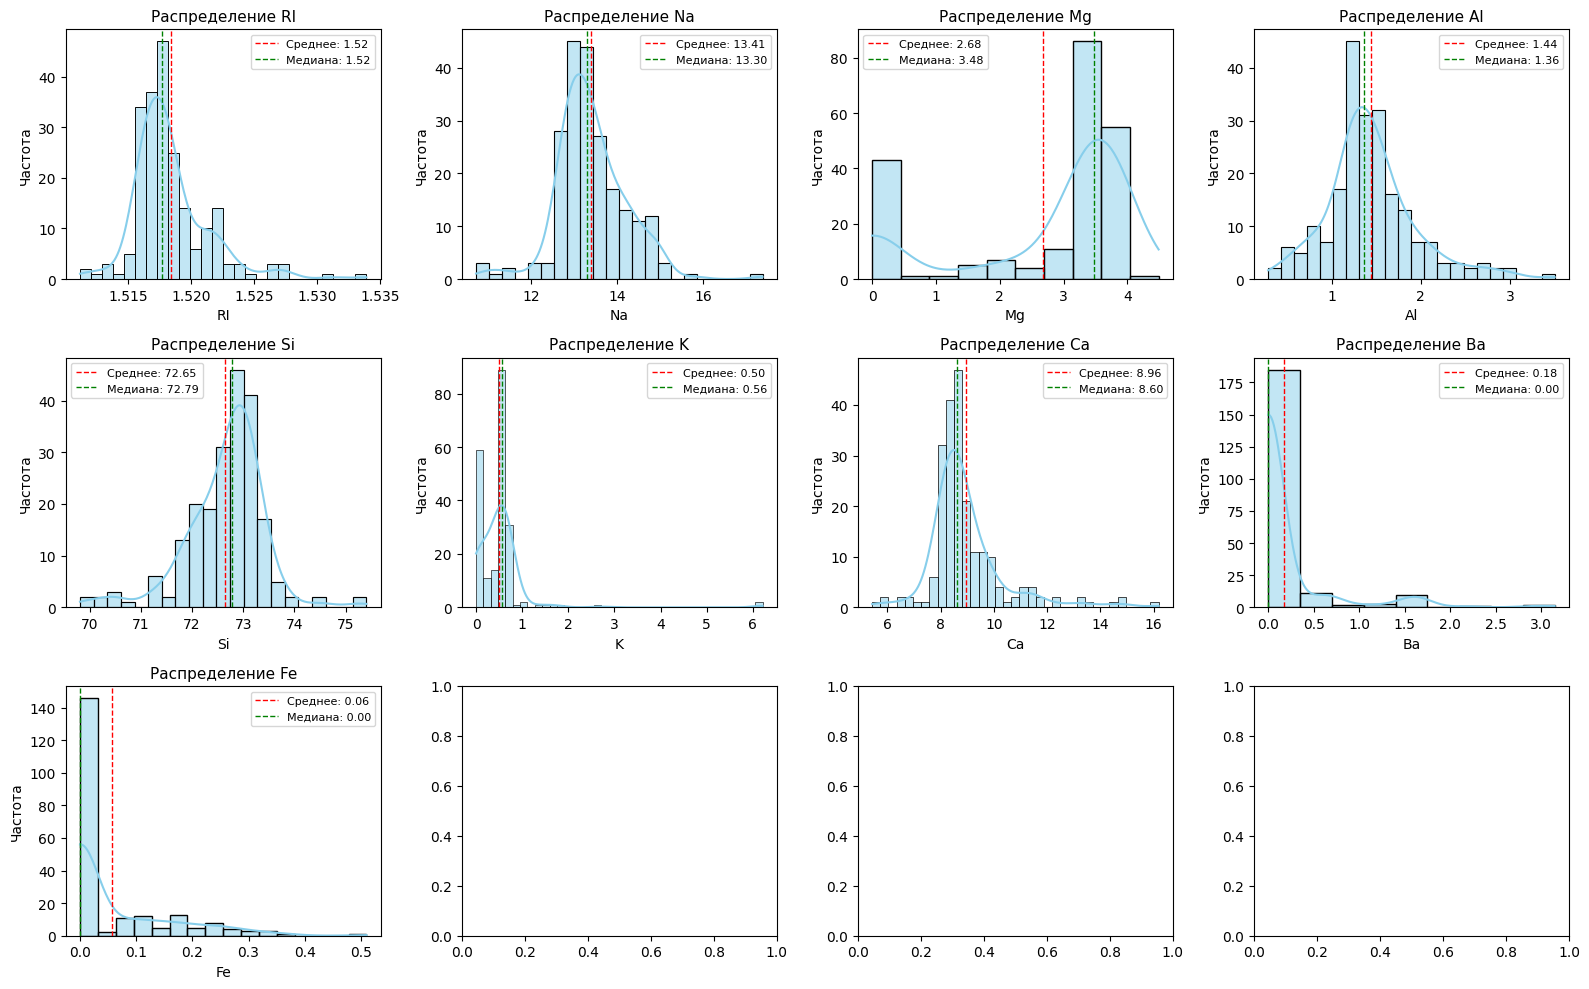

Выбросов по IQR (3*IQR): 51 (23.8%)


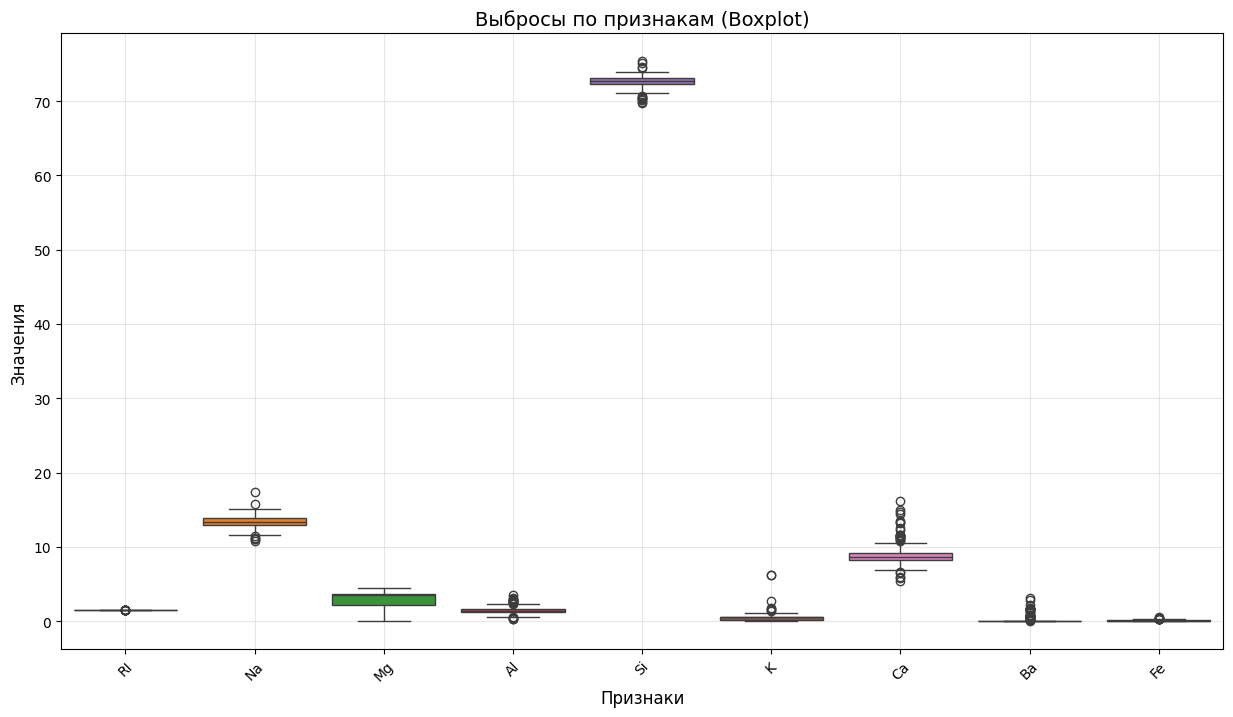


Процент удаленных записей по классам (IQR 3*):
Класс 1: 70 → 3 удалено (4.3%)
Класс 2: 76 → 13 удалено (17.1%)
Класс 3: 17 → 1 удалено (5.9%)
Класс 5: 13 → 6 удалено (46.2%)
Класс 6: 9 → 1 удалено (11.1%)
Класс 7: 29 → 27 удалено (93.1%)

Исходный размер: 214
После очистки: 163
Удалено записей: 51 (23.8%)

Распределение классов после очистки:
Type
1    67
2    63
3    16
5     7
6     8
7     2
Name: count, dtype: int64


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# а) Визуализация распределения с нормальными осями
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    ax = axes[i]
    # Гистограмма с KDE
    sns.histplot(data=X, x=col, ax=ax, kde=True, color='skyblue')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Частота', fontsize=10)
    ax.set_title(f'Распределение {col}', fontsize=11)

    # Добавим вертикальные линии для среднего и медианы
    mean_val = X[col].mean()
    median_val = X[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Среднее: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Медиана: {median_val:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# б) Исследование выбросов только IQR методом
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

# Менее строгий порог (3*IQR вместо 1.5*IQR)
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Выбросы за пределами 3*IQR
outliers_iqr = ((X < lower_bound) | (X > upper_bound)).any(axis=1)

print(f"Выбросов по IQR (3*IQR): {outliers_iqr.sum()} ({outliers_iqr.sum()/len(X)*100:.1f}%)")

# Визуализация выбросов с подписанными осями
plt.figure(figsize=(15, 8))
sns.boxplot(data=X)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.title('Выбросы по признакам (Boxplot)', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# в) Удаление выбросов (только действительно экстремальные)
X_clean = X[~outliers_iqr].copy()
y_clean = y[~outliers_iqr].copy()

# Процент удаленных записей для каждого класса
original_counts = y.value_counts().sort_index()
removed_counts = y[outliers_iqr].value_counts().sort_index()
percent_removed = (removed_counts / original_counts * 100).reindex(original_counts.index, fill_value=0)

print("\nПроцент удаленных записей по классам (IQR 3*):")
for cls in original_counts.index:
    orig = original_counts[cls]
    removed = removed_counts.get(cls, 0)
    pct = percent_removed[cls]
    print(f"Класс {cls}: {orig} → {removed} удалено ({pct:.1f}%)")

print(f"\nИсходный размер: {len(X)}")
print(f"После очистки: {len(X_clean)}")
print(f"Удалено записей: {len(X) - len(X_clean)} ({(len(X) - len(X_clean))/len(X)*100:.1f}%)")

# Проверка баланса классов после очистки
print("\nРаспределение классов после очистки:")
print(y_clean.value_counts().sort_index())

## Переобучение на очищенной выборке

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model_clean = RandomForestClassifier(random_state=42)
rf_model_clean.fit(X_clean, y_clean)


y_pred_rf_clean = rf_model.predict(X_test)

print('На неочищенной выборке')
print (classification_report(y_test, y_pred_rf))

print('На очищенной выборке')
print (classification_report(y_test, y_pred_rf_clean))


На неочищенной выборке
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43

На очищенной выборке
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                     

## Удаление признаков, у которых нет нормального распределения

In [33]:
# Признаки с нормальным распределением
normal_features = ['RI', 'Na', 'Al', 'Si', 'Ca']

# Создаем новые выборки только с нормальными признаками
X_normal = X[normal_features].copy()

# Обновляем X_train и X_test
X_train_normal = X_train[normal_features].copy()
X_test_normal = X_test[normal_features].copy()

# Проверяем размерности
print(f"Исходные признаки: {X.shape[1]}")
print(f"Признаки с нормальным распределением: {X_normal.shape[1]}")
print(f"Удалены признаки: {set(X.columns) - set(normal_features)}")

# Обучение модели только на нормальных признаках
rf_normal = RandomForestClassifier(random_state=42)
rf_normal.fit(X_train_normal, y_train)

y_pred_normal = rf_normal.predict(X_test_normal)

print('На неочищенной выборке')
print (classification_report(y_test, y_pred_rf))

print('Результаты только с нормально распределенными признаками:')
print(classification_report(y_test, y_pred_normal))



Исходные признаки: 9
Признаки с нормальным распределением: 5
Удалены признаки: {'Mg', 'Fe', 'Ba', 'K'}
На неочищенной выборке
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43

Результаты только с нормально распределенными признаками:
              precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.73      0.73      0.73        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
  